In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


In [5]:
class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

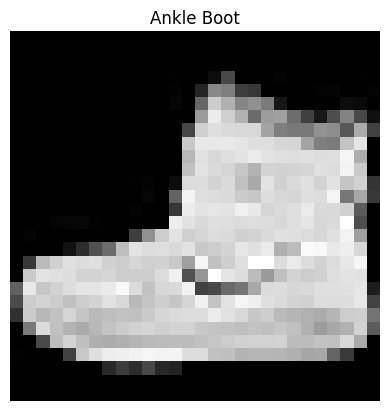

In [6]:
plt.imshow(X_train[0], cmap='gray')
plt.title(class_names[y_train[0]])
plt.axis('off')
plt.show()

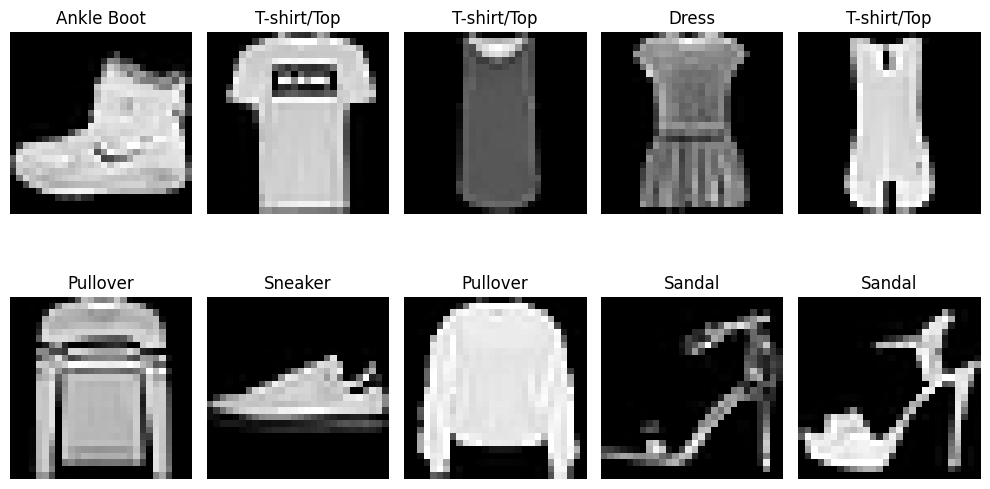

In [7]:
plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(class_names[y_train[i]])

    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [26]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='softmax')
])

In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6605 - loss: 0.9045 - val_accuracy: 0.7813 - val_loss: 0.5947
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.7866 - loss: 0.5796 - val_accuracy: 0.8111 - val_loss: 0.5106
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8150 - loss: 0.5091 - val_accuracy: 0.8313 - val_loss: 0.4591
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8303 - loss: 0.4649 - val_accuracy: 0.8419 - val_loss: 0.4301
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8406 - loss: 0.4367 - val_accuracy: 0.8479 - val_loss: 0.4137
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8486 - loss: 0.4139 - val_accuracy: 0.8532 - val_loss: 0.3921
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8541 - loss: 0.3993 - val_accuracy: 0.8559 - val_loss: 0.3899
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8597 - loss: 0.

In [35]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8352 - loss: 0.4383
Test Accuracy: 0.8352000117301941
Test Loss: 0.438277930021286


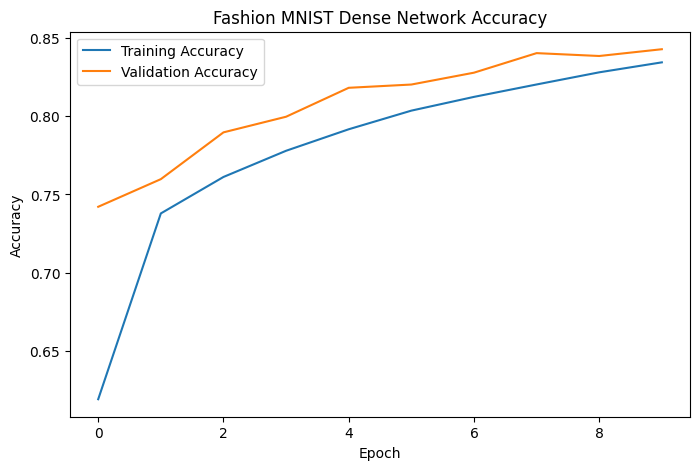

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Fashion MNIST Dense Network Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

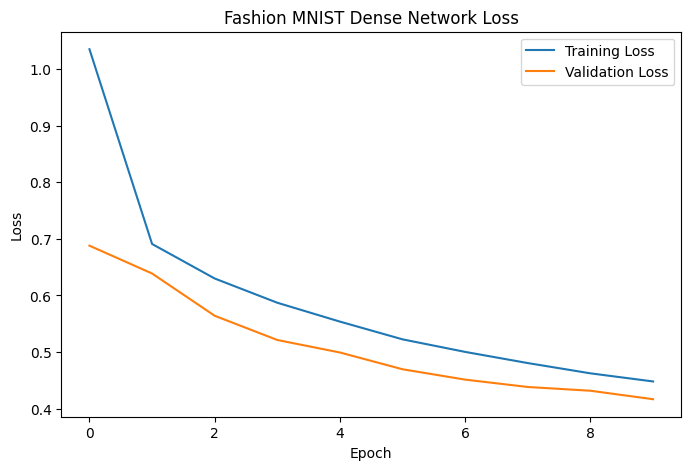

In [38]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Fashion MNIST Dense Network Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [41]:
import numpy as np

index = 0

predicted_class = np.argmax(predictions[index])

print("Predicted:", predicted_class)
print("Actual:", y_test[index])

Predicted: 9
Actual: 9


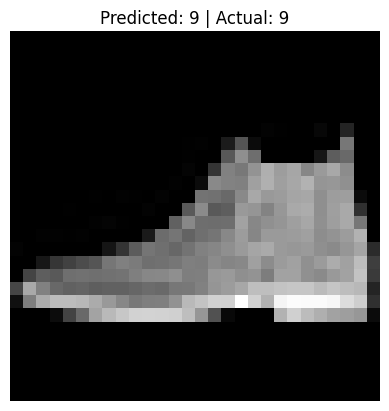

In [42]:
plt.imshow(X_test[index], cmap='gray')
plt.title(f"Predicted: {predicted_class} | Actual: {y_test[index]}")
plt.axis('off')
plt.show()

In [43]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

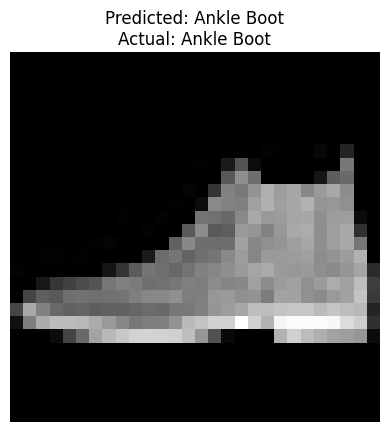

In [44]:
plt.imshow(X_test[index], cmap='gray')

plt.title(
    f"Predicted: {class_names[predicted_class]}\nActual: {class_names[y_test[index]]}"
)

plt.axis('off')

plt.show()

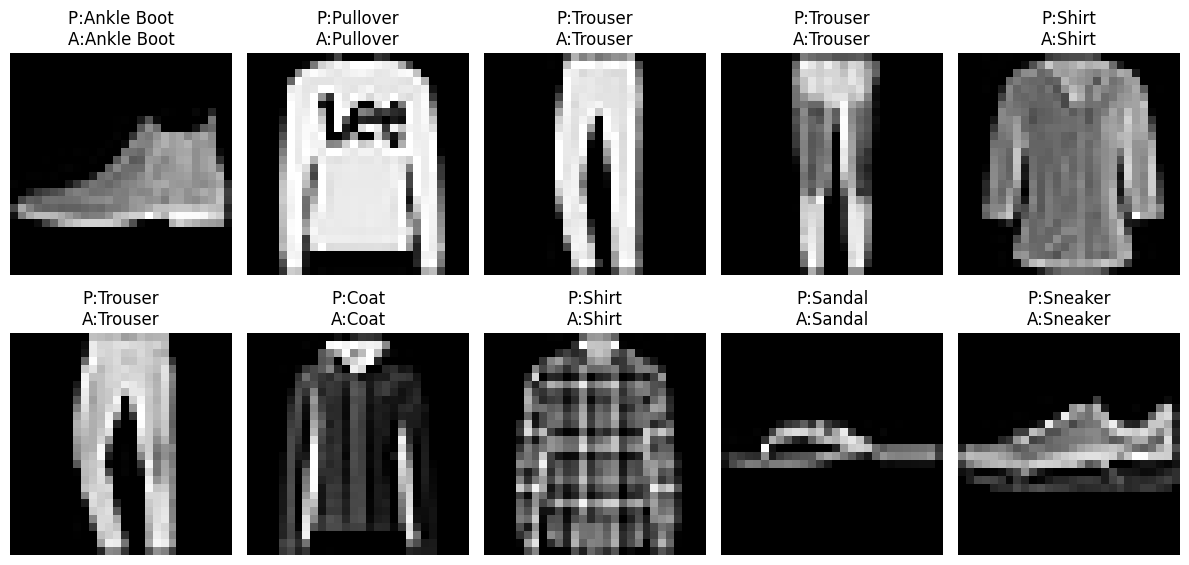

In [45]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap='gray')

    pred = np.argmax(predictions[i])

    plt.title(
        f"P:{class_names[pred]}\nA:{class_names[y_test[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()